In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

from datetime import datetime
from isoweek import Week
from cmdstanpy import CmdStanModel
from cmdstanpy import from_csv
import glob

In [2]:
@njit
def get_noise_draws(noise_level, T, dt):
    alpha = dt / noise_level**2
    beta = noise_level**2
    k_shape = alpha
    theta_scale = beta
    noise_draws = np.empty(T)
    for i in range(T):
        DeltaGamma_loc = np.random.gamma(k_shape, theta_scale)
        noise_draws[i] = DeltaGamma_loc / dt
    return noise_draws

@njit
def sirs_ode(t, S, I, R, beta0, dbeta, betaphase, gamma, mu, delta, noise_draw):
    beta_t = beta0 * (1 + dbeta * np.sin(2 * np.pi * t / 52 + betaphase)) * noise_draw
    dSdt = mu - beta_t * S * I - mu * S + delta * R
    dIdt = beta_t * S * I - (mu + gamma) * I
    dRdt = gamma * I - (mu + delta) * R
    return dSdt, dIdt, dRdt, beta_t

@njit
def sirs_run(beta0, dbeta, betaphase, gamma, mu, delta, 
                            S0, I0, noise_draws, dt=0.05, total_time=20*52, t0=0.0):
    # number of steps
    N = int(total_time / dt)
    
    S, I, R = S0, I0, 1 - S0 - I0
    
    S_timeseries = np.full(N+1, np.nan)
    I_timeseries = np.full(N+1, np.nan)
    R_timeseries = np.full(N+1, np.nan)
    ts = np.full(N+1, np.nan)
    ts[0] = t0
    S_timeseries[0] = S
    I_timeseries[0] = I
    R_timeseries[0] = R
    
    t = t0
    for k in range(1, N+1):
        # compute the ODE derivatives
        noise_draw = noise_draws[k]
        f = sirs_ode(t, S, I, R, beta0, dbeta, betaphase, gamma, mu, delta, noise_draw)
        
        S += dt * f[0]
        I += dt * f[1]
        R += dt * f[2]
        
        t += dt
        ts[k] = t
        S_timeseries[k] = S
        I_timeseries[k] = I
        R_timeseries[k] = R
    
    return ts, S_timeseries, I_timeseries, R_timeseries

In [3]:
dt_discrete = 1/8

In [4]:
csv_files = glob.glob('/storage/mycoplasma/sinusoid_2025/output/*20250801092152*.csv')  # dt=1/8, better prior for S0, 3000 iterations, good diagnostics all around 

print(csv_files)

fit = from_csv(csv_files)

['/storage/mycoplasma/sinusoid_2025/output/sirs_sinusoid_dt-20250801092152_3.csv', '/storage/mycoplasma/sinusoid_2025/output/sirs_sinusoid_dt-20250801092152_2.csv', '/storage/mycoplasma/sinusoid_2025/output/sirs_sinusoid_dt-20250801092152_4.csv', '/storage/mycoplasma/sinusoid_2025/output/sirs_sinusoid_dt-20250801092152_1.csv']


In [6]:
for var in ['S0', 'logx_I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'rho', 'delta']:
#for var in ['S0', 'I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'rho', 'tau']:
    print(f"{var}: {fit.stan_variable(var).mean()}")

S0: 0.6458905435
logx_I0: -2.6409258616666667
beta0: 0.649645859
dbeta: 0.18228653116666668
betaphase: 3.6441056533333334
sigma_obs: 0.016210041683333332
rho: 0.021266319516666667
delta: 0.0023089227783333333


In [7]:
df_draws = fit.draws_pd()
lp = df_draws["lp__"]  # log posterior column
imax = np.argmax(lp)  # index of sample with highest lp__
best_draw = df_draws.iloc[imax]

In [8]:
import re

def best_draw_to_dict(row):
    """
    Convert a series of Stan draws into a structured dict,
    grouping vector parameters like param[1], param[2], ... into arrays.
    """
    result = {}
    for col in row.index:
        # Attempt to match something like "paramName[123]"
        m = re.match(r"(.*)\[(\d+)\]$", col)
        if m:
            base_name = m.group(1)
            idx = int(m.group(2))  # 1-based index from Stan
            val = row[col]

            if base_name not in result:
                # store them in a dict first, convert to array after.
                result[base_name] = {}
            result[base_name][idx] = val
        else:
            # it is a scalar param or a special column like chain__, iter__, ...
            result[col] = row[col]

    # Convert any dict-of-indices to a list or array
    # Stan uses 1-indexing
    for k, v in list(result.items()):
        if isinstance(v, dict):
            # v is a dictionary of indices -> values
            max_idx = max(v.keys())
            # create an array of length = max index
            arr = np.empty(max_idx, dtype=float)
            for i in range(1, max_idx + 1):
                arr[i - 1] = v[i]  # shift to zero-indexing
            result[k] = arr
    return result

best_draw_dict = best_draw_to_dict(best_draw)


In [9]:
def DiscTimeRate(r, dt):
    return (1 - np.exp(-r*dt))/dt

In [10]:
# We must translate rates into their continuous time versions: 
def DiscRateToCont(r, dt):
    return (1 - np.exp(-r*dt))/dt


mu = DiscTimeRate(1/(52 * 80.0), dt_discrete)

with_seasonality = True

beta0 = DiscTimeRate(best_draw_dict['beta0'], dt_discrete)
betaphase = best_draw_dict['betaphase']
gamma = DiscTimeRate(best_draw_dict['gamma'], dt_discrete)
delta = DiscTimeRate(best_draw_dict['delta'], dt_discrete)
S0 = best_draw_dict['S0']
I0 = best_draw_dict['I0']



if with_seasonality:
    dbeta = best_draw_dict['dbeta']
else:
    dbeta = 0.0

In [11]:
dt = 0.05
total_time = 52*75
noise_level = 0.0000001
#noise_level = 0.12

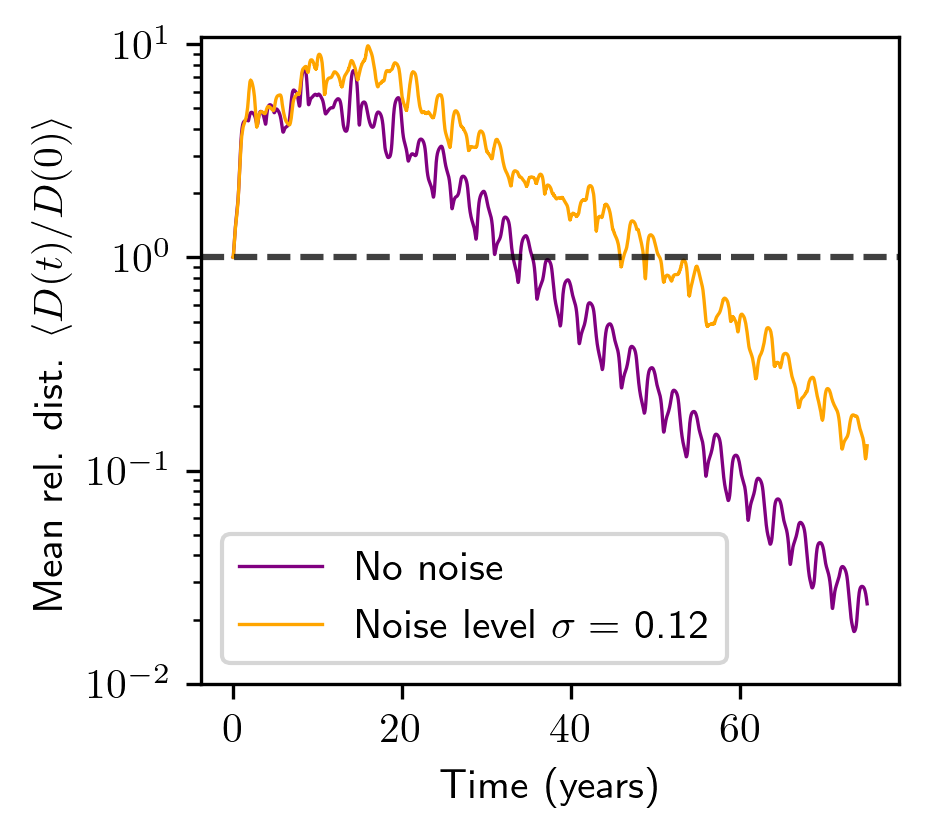

In [12]:
from copy import deepcopy



log_avg = False

# Initial conditions
IC_steps = 7
#IC_steps = 100
initial_conditions = [
    (S0, I0) for S0 in np.linspace(0.5, 0.7, IC_steps)  # Vary S0
    for I0 in np.logspace(-5, -2, IC_steps)              # Vary I0
    #(S0, I0) for S0 in np.linspace(0.5, 0.6, IC_steps)  # Vary S0
    #for I0 in np.logspace(-4, -2, IC_steps)              # Vary I0
    if S0 + I0 <= 1
]


n_repeats = 10
n_trials = len(initial_conditions) * n_repeats

fig = plt.figure(figsize=(3,2.8), dpi=300)

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": """\\usepackage{braket}""",
    #"font.family": "Helvetica"
    "font.family": "sans-serif"
})

Nt = int(total_time / dt)

max_mean_dist=0
for noise_level in [0.00001, 0.12]:
    i=0
    for S0_loc, I0_loc in initial_conditions:
        for rep in range(n_repeats):
            noise_draws = get_noise_draws(noise_level, Nt+1, dt)
            noise_draws_2 = deepcopy(noise_draws)
            
            ##### EXPERIMENT -- different noise at single time point 
            #noise_draws_fake = get_noise_draws(noise_level, Nt+1, dt)
            #idx_change = int(len(noise_draws)/3)
            #noise_draws_2[idx_change] = noise_draws_fake[idx_change]
            
            ts, Ss, Is, Rs = sirs_run(beta0, dbeta, betaphase, gamma, mu, delta, 
                                           S0_loc, I0_loc, noise_draws, dt=dt, total_time=total_time)
            
            
            dS = 0.001*(2*np.random.random()-1) * S0_loc
            dI = 0.1*(2*np.random.random()-1) * I0_loc
            
            ts, Ss_2, Is_2, Rs_2 = sirs_run(beta0, dbeta, betaphase, gamma, mu, delta, 
                                       S0_loc+dS, I0_loc+dI, noise_draws_2, dt=dt, total_time=total_time)
            
            
            dist = np.sqrt((Ss_2-Ss)**2 + (Is_2-Is)**2)

            dist /= dist[0]
            if log_avg:
                if i==0:
                    dist_mean = np.log(dist)/n_trials
                else:
                    dist_mean += np.log(dist)/n_trials
            else:
                if i==0:
                    dist_mean = dist/n_trials
                else:
                    dist_mean += dist/n_trials
            i += 1

    if noise_level < 0.01:
        noise_str = "No noise"
        col = "purple"
    else:
        noise_str = rf"Noise level $\sigma=$ {round(noise_level,2)}"
        col = "orange"
    max_mean_dist = max(np.max(dist_mean), max_mean_dist)
    plt.plot(ts/52, dist_mean, alpha=1.0, lw=0.8, label=noise_str, color=col)


plt.xlabel("Time (years)")

if log_avg:
    plt.axhline(0, color="black", ls="--", alpha=0.75, zorder=2)
    plt.ylabel(r"Mean log rel. dist. $\Braket{\log[D(t)/D(0)]}$")
else:
    plt.yscale('log')
    plt.ylabel(r"Mean rel. dist. $\Braket{D(t)/D(0)}$")
    plt.ylim([1/100, 1.1*max_mean_dist])
    plt.axhline(1, color="black", ls="--", alpha=0.75, zorder=2)
plt.legend(loc="lower left")

#plt.axvline(ts[idx_change]/52, ls="--", alpha=0.5, color="black")